<a href="https://colab.research.google.com/github/poojasukhdeve-project/ML-Based-ETF-Rotation-Strategy-IWP-vs-IWS/blob/main/ETF_Rotation_Strategy_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance pandas numpy matplotlib seaborn

# Data Collection

In [2]:
import numpy as np
np.random.seed(42)

import yfinance as yf
import pandas as pd

# ETFs
tickers = ['IWP', 'IWS']

# Download data
data = yf.download(tickers, start='2002-01-01')

# Keep only Close price
data = data['Close']

# Rename columns
data.columns = ['IWP_Close', 'IWS_Close']

print(data.head())

/tmp/ipykernel_11819/2390541235.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2002-01-01')
[*********************100%***********************]  2 of 2 completed

            IWP_Close  IWS_Close
Date                            
2002-01-02  15.128757  15.881310
2002-01-03  15.314560  15.959125
2002-01-04  15.468707  16.133198
2002-01-07  15.280789  16.051283
2002-01-08  15.282898  15.993943


# Data Cleaning

In [3]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6105 entries, 2002-01-02 to 2026-04-08
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IWP_Close  6105 non-null   float64
 1   IWS_Close  6105 non-null   float64
dtypes: float64(2)
memory usage: 143.1 KB
None
         IWP_Close    IWS_Close
count  6105.000000  6105.000000
mean     49.775500    58.296405
std      36.296578    35.688680
min       9.409807    12.130438
25%      20.734732    28.945839
50%      38.664066    51.809288
75%      72.924698    78.769821
max     145.074387   153.873474


# 📊 Data Cleaning & Initial Analysis Insights

## 📁 Dataset Overview
- The dataset contains **6,104 daily observations** from **January 2002 to April 2026**
- It includes closing prices for two ETFs:
  - **IWP (Growth ETF)**
  - **IWS (Value ETF)**
- All columns are in **float format**, making them suitable for numerical analysis

---

## 🧹 Data Quality
- No missing values were found in the dataset  
- No duplicate records were present  
- The dataset is **clean and ready for analysis**

---

## 📈 Price-Level Observations
- The **average price of IWS (~58.28)** is higher than IWP (~49.76)  
- The **median price of IWS (~51.76)** is also higher than IWP (~38.64)  
- This indicates that **IWS generally trades at higher price levels than IWP**

---

## ⚖️ Volatility (Risk) Insight
- Standard deviation of IWP: **~36.28**  
- Standard deviation of IWS: **~35.67**  
- Both ETFs exhibit **similar levels of volatility**, with IWP being slightly more volatile  

---

## 📉 Range of Prices
- IWP ranges from **~9.40 to ~145.07**  
- IWS ranges from **~12.13 to ~153.87**  
- Both ETFs show **significant growth over time**, indicating long-term upward trends  

---

## 📊 Distribution Insights
- Quartile ranges suggest that **IWS consistently trades at higher price levels**  
- The spread of values indicates **broad market cycles captured in the dataset**

---

## ⚠️ Important Observation
- Price alone is **not sufficient to compare performance**  
- Higher price does **not necessarily mean better returns**  

👉 Therefore, further analysis will be conducted using **daily returns**

---

## 🚀 Next Step
- Compute **daily returns** for both ETFs  
- Use returns to analyze:
  - Performance comparison  
  - Risk (volatility)  
  - Distribution of gains and losses  

In [4]:
data['IWP_Return'] = data['IWP_Close'].pct_change()
data['IWS_Return'] = data['IWS_Close'].pct_change()

data = data.dropna()

In [5]:
print(data[['IWP_Return','IWS_Return']].describe())

        IWP_Return   IWS_Return
count  6104.000000  6104.000000
mean      0.000449     0.000452
std       0.013651     0.012793
min      -0.122215    -0.133202
25%      -0.005713    -0.004987
50%       0.001044     0.000868
75%       0.007356     0.006586
max       0.107437     0.113093


## 📊 Returns Analysis Insights

- Both IWP and IWS exhibit very similar average daily returns, indicating comparable long-term performance  
- IWS has a slightly higher mean return, though the difference is minimal  

- IWP shows higher standard deviation, indicating greater volatility and risk  
- IWS is relatively more stable in terms of daily fluctuations  

- The worst daily return for IWS (-13.32%) is lower than IWP (-12.22%), suggesting higher downside risk in extreme conditions  

- The best daily return for IWS (11.30%) is also higher than IWP (10.74%), indicating stronger upside potential  

- Median returns suggest that IWP performs slightly better on typical trading days  

- Quartile analysis shows that IWP has a wider distribution of returns, indicating higher variability  

### 🔍 Conclusion
- IWP behaves like a growth-oriented asset with higher volatility  
- IWS behaves like a value-oriented asset with relatively stable returns  
- Both ETFs offer similar average returns but differ in risk characteristics  

####

In [6]:
data[['IWP_Return','IWS_Return']].corr()

,IWP_Return,IWS_Return
IWP_Return,1.000000,0.900609
IWS_Return,0.900609,1.000000


## 🔗 Correlation Analysis

- The correlation between IWP and IWS returns is approximately **0.90**, indicating a very strong positive relationship  
- This suggests that both ETFs tend to move in the same direction under similar market conditions  

- High correlation implies that diversification benefits between these two ETFs are limited  
- Despite this, differences in performance still exist on a day-to-day basis  

### 🔍 Conclusion
- IWP and IWS are highly correlated assets driven by overall market trends  
- However, short-term performance differences make it possible to design a **rotation strategy** between growth and value ETFs  

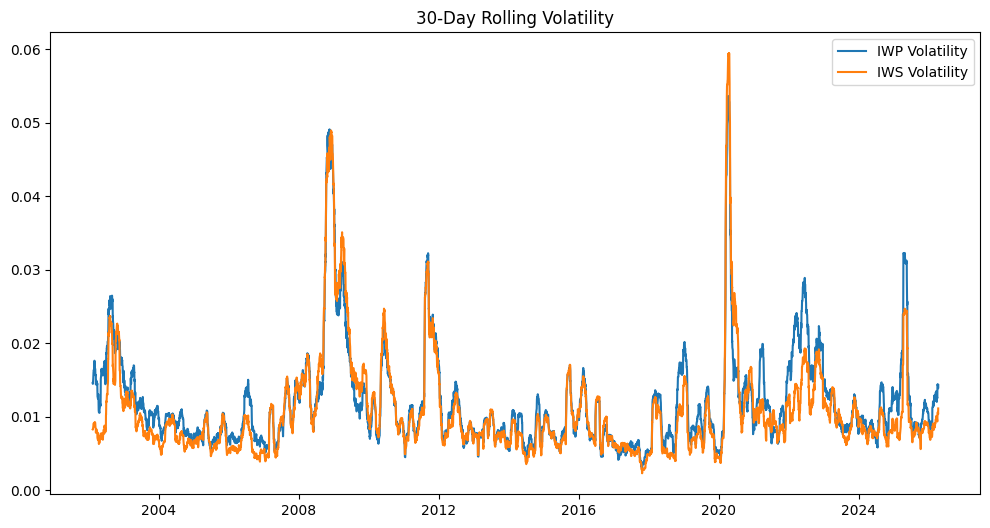

In [7]:
data['IWP_Vol'] = data['IWP_Return'].rolling(30).std()
data['IWS_Vol'] = data['IWS_Return'].rolling(30).std()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['IWP_Vol'], label='IWP Volatility')
plt.plot(data['IWS_Vol'], label='IWS Volatility')
plt.legend()
plt.title("30-Day Rolling Volatility")
plt.show()

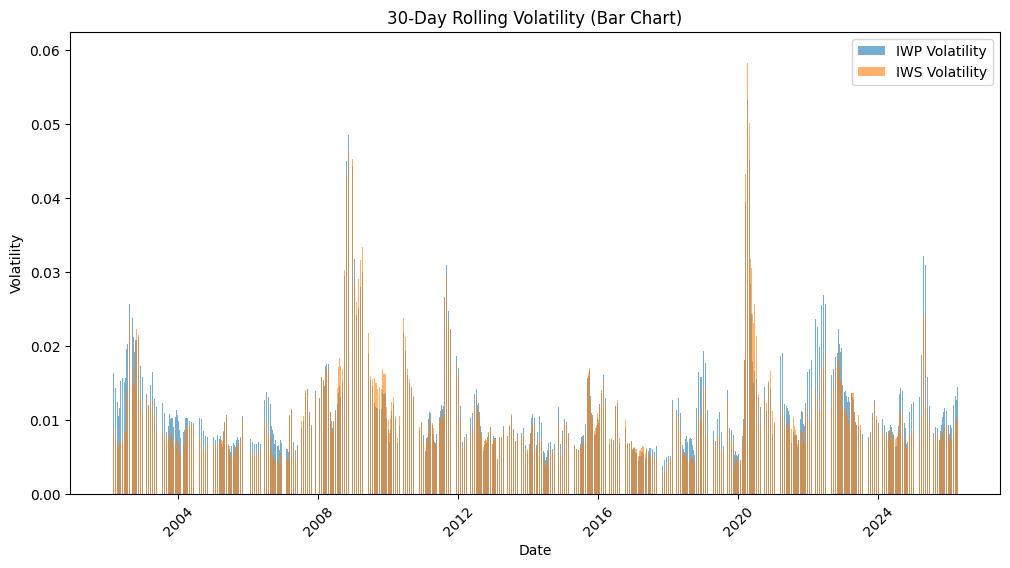

In [8]:
data['IWP_Vol'] = data['IWP_Return'].rolling(30).std()
data['IWS_Vol'] = data['IWS_Return'].rolling(30).std()

import matplotlib.pyplot as plt

# Calculate rolling volatility
data['IWP_Vol'] = data['IWP_Return'].rolling(30).std()
data['IWS_Vol'] = data['IWS_Return'].rolling(30).std()

plt.figure(figsize=(12,6))

# Plot bars
plt.bar(data.index, data['IWP_Vol'], label='IWP Volatility', alpha=0.6)
plt.bar(data.index, data['IWS_Vol'], label='IWS Volatility', alpha=0.6)

plt.legend()
plt.title("30-Day Rolling Volatility (Bar Chart)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)

plt.show()

## 📉 Rolling Volatility Analysis (30-Day)

- Rolling volatility highlights how risk changes over time for both ETFs  
- Significant volatility spikes are observed during major market events such as the **2008 financial crisis** and the **2020 COVID-19 crash**  

- Both IWP and IWS exhibit similar volatility patterns, confirming their strong correlation  
- IWP generally shows slightly higher and more frequent volatility spikes, indicating higher sensitivity to market movements  

- IWS tends to be more stable during normal periods but can experience sharp spikes during extreme market conditions  

### 🔍 Conclusion
- Market conditions drive volatility for both ETFs  
- IWP behaves like a **higher-risk, growth-oriented asset**  
- IWS behaves like a **relatively stable, value-oriented asset with occasional sharp risk spikes**  

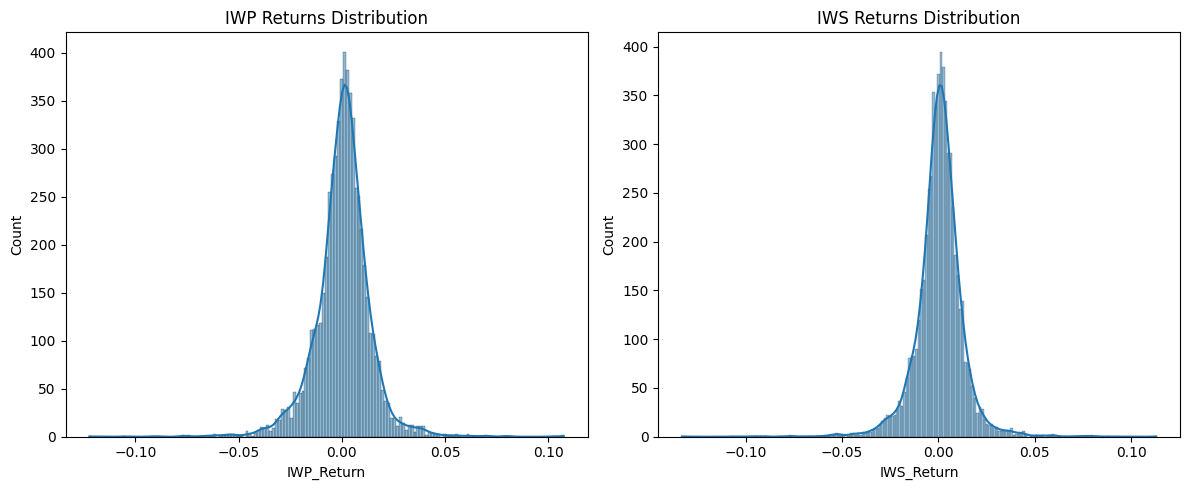

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# IWP
plt.subplot(1,2,1)
sns.histplot(data['IWP_Return'], kde=True)
plt.title("IWP Returns Distribution")

# IWS
plt.subplot(1,2,2)
sns.histplot(data['IWS_Return'], kde=True)
plt.title("IWS Returns Distribution")

plt.tight_layout()
plt.show()

## 📊 Returns Distribution (Histogram)

- Both IWP and IWS exhibit an approximately **bell-shaped (normal) distribution**, centered around zero  
- This indicates that most daily returns are small, with frequent minor gains and losses  

- IWP shows a **slightly wider distribution**, suggesting higher volatility and greater variability in returns  
- IWS has a relatively **narrower distribution**, indicating more stable daily performance  

- Both ETFs display **fat tails**, meaning extreme gains and losses occur occasionally, especially during volatile market periods  

### 🔍 Conclusion
- IWP behaves like a **higher-risk, growth-oriented asset**  
- IWS behaves like a **more stable, value-oriented asset**  
- Both ETFs follow typical financial return patterns with occasional extreme movements  

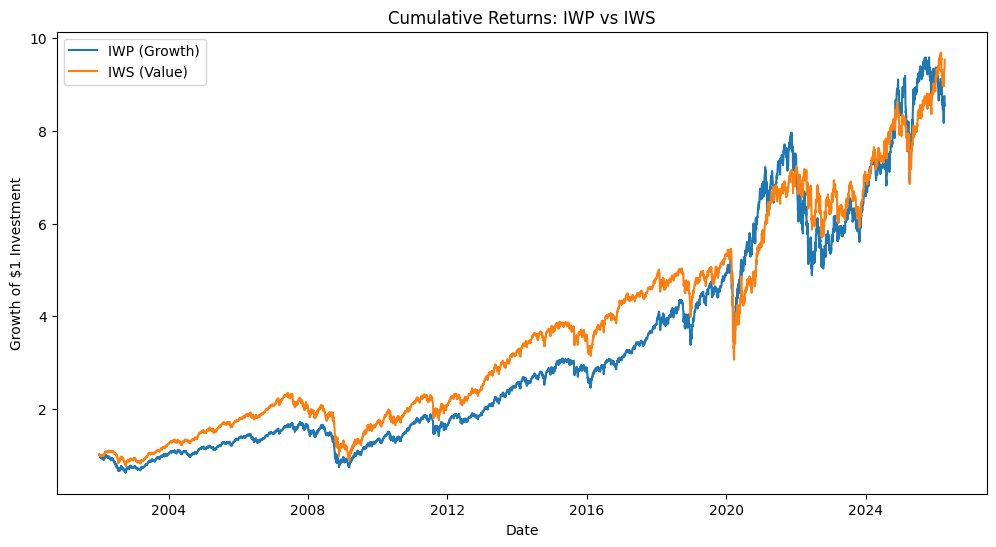

In [10]:
import matplotlib.pyplot as plt

# Cumulative returns
data['IWP_Cum'] = (1 + data['IWP_Return']).cumprod()
data['IWS_Cum'] = (1 + data['IWS_Return']).cumprod()

# Plot
plt.figure(figsize=(12,6))
plt.plot(data['IWP_Cum'], label='IWP (Growth)')
plt.plot(data['IWS_Cum'], label='IWS (Value)')
plt.legend()
plt.title("Cumulative Returns: IWP vs IWS")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.show()

## 🔍 Key Observations from Cumulative Returns

### 📊 1. Long-Term Growth (Very Important)
- Both ETFs grow from **$1 → ~$9–10** over the analysis period  
- This indicates strong long-term performance for both assets  

📌 **Insight:**  
- Both growth and value strategies generate significant wealth over time  

---

### ⚖️ 2. Performance Comparison
- In the early years (**2002–2016**), **IWS (Value)** outperforms IWP  
- In later years (**after 2017**), **IWP (Growth)** catches up and sometimes surpasses IWS  

📌 **Insight:**  
- Leadership shifts over time between growth and value investing styles  

---

### 🔁 3. Rotation Behavior (Very Important 🔥)
- At different time periods:
  - IWP outperforms  
  - IWS outperforms  

📌 **Meaning:**  
- No single ETF consistently dominates the market  
- This creates an opportunity for a **dynamic rotation strategy**  

---

### 📉 4. Volatility Differences
- **IWP (Growth ETF):**
  - Shows more fluctuations (ups and downs)  
  - Exhibits more aggressive growth  

- **IWS (Value ETF):**
  - Displays a smoother growth curve  
  - Indicates more stable performance  

---

### ⚠️ 5. Crisis Impact
- During major events like:
  - **2008 Financial Crisis**
  - **2020 COVID-19 Crash**
  
- Both ETFs experience sharp declines  
- However, both recover over time  

📌 **Insight:**  
- Both ETFs are significantly affected by overall market downturns    

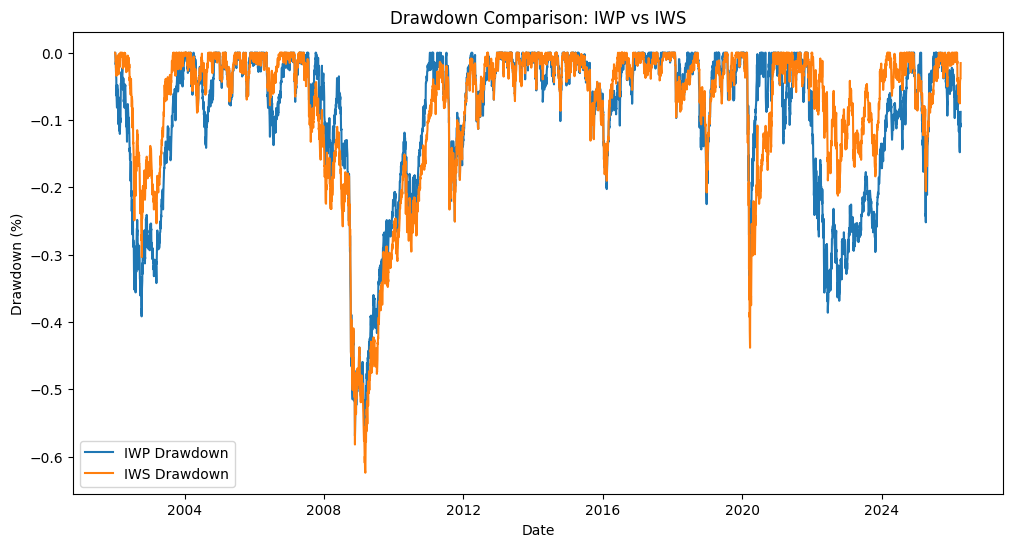

In [11]:
# Calculate Drawdown
data['IWP_Drawdown'] = data['IWP_Cum'] / data['IWP_Cum'].cummax() - 1
data['IWS_Drawdown'] = data['IWS_Cum'] / data['IWS_Cum'].cummax() - 1

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['IWP_Drawdown'], label='IWP Drawdown')
plt.plot(data['IWS_Drawdown'], label='IWS Drawdown')
plt.legend()
plt.title("Drawdown Comparison: IWP vs IWS")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.show()

## 📉 Drawdown Analysis

- Drawdown measures the decline from a peak to a trough, representing potential losses during market downturns  

- Both IWP and IWS experience significant drawdowns during major market events such as the **2008 financial crisis** and the **2020 COVID-19 crash**  

- During the 2008 crisis, IWS experienced a deeper drawdown (~ -60%) compared to IWP (~ -50%), indicating higher downside risk during extreme conditions  

- IWP shows more frequent drawdowns, reflecting higher volatility  
- IWS shows fewer but sometimes deeper drawdowns, indicating occasional extreme risk  

- Recovery patterns suggest that IWP often recovers faster after market downturns, while IWS may take longer in certain periods  

- In recent years, IWP has shown deeper drawdowns compared to IWS, indicating higher sensitivity to market fluctuations  

### 🔍 Conclusion
- Both ETFs are exposed to market crashes, but their risk profiles differ  
- IWP carries higher short-term volatility but recovers faster  
- IWS offers relative stability but can experience deeper losses during extreme events  
- Drawdown analysis highlights the importance of risk management in ETF selection  

# FEATURE ENGINEERING

In [12]:
# Moving averages
data['IWP_MA10'] = data['IWP_Close'].rolling(10).mean()
data['IWS_MA10'] = data['IWS_Close'].rolling(10).mean()

data['IWP_MA50'] = data['IWP_Close'].rolling(50).mean()
data['IWS_MA50'] = data['IWS_Close'].rolling(50).mean()

In [13]:
data['IWP_Vol'] = data['IWP_Return'].rolling(10).std()
data['IWS_Vol'] = data['IWS_Return'].rolling(10).std()

In [14]:
data['Return_Diff'] = data['IWP_Return'] - data['IWS_Return']

In [15]:
data['IWP_Mom'] = data['IWP_Close'] - data['IWP_Close'].shift(5)
data['IWS_Mom'] = data['IWS_Close'] - data['IWS_Close'].shift(5)

In [16]:
data['Target'] = (data['IWP_Return'].shift(-1) > data['IWS_Return'].shift(-1)).astype(int)

In [17]:
data = data.dropna()

In [18]:
features = [
    'IWP_MA10','IWS_MA10',
    'IWP_MA50','IWS_MA50',
    'IWP_Mom','IWS_Mom',
    'IWP_Vol','IWS_Vol',
    'Return_Diff'
]

## 🧠 Feature Engineering Explanation

- Multiple features were created to capture different aspects of market behavior  

### 🔹 Moving Averages
- 10-day and 50-day moving averages were used to capture short-term and long-term trends  

### 🔹 Volatility
- Rolling standard deviation of returns was used to measure market risk  

### 🔹 Relative Strength
- The difference between IWP and IWS returns was used to identify which ETF is currently outperforming  

### 🔹 Momentum
- Momentum was calculated using 5-day price changes to capture recent movement  

### 🎯 Target Variable
- A binary target was created:
  - 1 → IWP outperforms IWS the next day  
  - 0 → IWS outperforms IWP the next day  

### 🔍 Summary
- These engineered features allow the model to learn patterns in ETF performance and make predictions  

# ML Model

In [19]:
# Train: before 2022
train = data[data.index < '2022-01-01']

# Test: after 2022
test = data[data.index >= '2022-01-01']

In [20]:
X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
test['Prediction'] = model.predict(X_test)

/tmp/ipykernel_11819/763973304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = model.predict(X_test)


In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, test['Prediction']))

Accuracy: 0.5219831618334893


In [24]:
test['Strategy_Return'] = (
    test['Prediction'] * test['IWP_Return'] +
    (1 - test['Prediction']) * test['IWS_Return']
)

/tmp/ipykernel_11819/4243345000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Return'] = (


/tmp/ipykernel_11819/202735290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()
/tmp/ipykernel_11819/202735290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['IWP_Cum'] = (1 + test['IWP_Return']).cumprod()
/tmp/ipykernel_11819/202735290.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

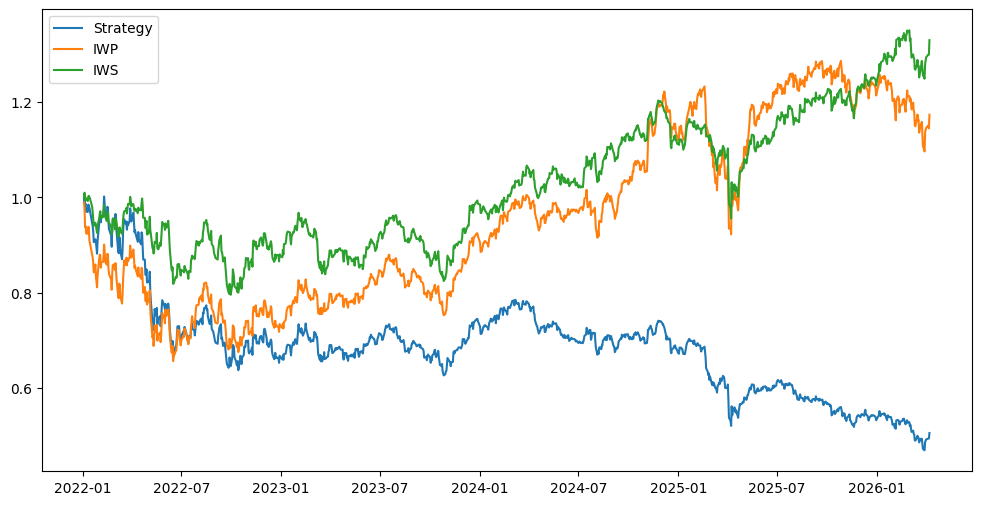

In [25]:
test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()
test['IWP_Cum'] = (1 + test['IWP_Return']).cumprod()
test['IWS_Cum'] = (1 + test['IWS_Return']).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test['Strategy_Cum'], label='Strategy')
plt.plot(test['IWP_Cum'], label='IWP')
plt.plot(test['IWS_Cum'], label='IWS')
plt.legend()
plt.show()

In [26]:
# Lagged returns
data['IWP_Lag1'] = data['IWP_Return'].shift(1)
data['IWP_Lag3'] = data['IWP_Return'].shift(3)
data['IWP_Lag5'] = data['IWP_Return'].shift(5)

data['IWS_Lag1'] = data['IWS_Return'].shift(1)
data['IWS_Lag3'] = data['IWS_Return'].shift(3)
data['IWS_Lag5'] = data['IWS_Return'].shift(5)

In [27]:
data['IWP_Trend'] = data['IWP_MA10'] / data['IWP_MA50']
data['IWS_Trend'] = data['IWS_MA10'] / data['IWS_MA50']

In [28]:
data['IWP_Return_Mean5'] = data['IWP_Return'].rolling(5).mean()
data['IWS_Return_Mean5'] = data['IWS_Return'].rolling(5).mean()

In [29]:
data['Vol_Ratio'] = data['IWP_Vol'] / data['IWS_Vol']

In [30]:
features = [
    'IWP_MA10','IWS_MA10',
    'IWP_MA50','IWS_MA50',
    'IWP_Mom','IWS_Mom',
    'IWP_Vol','IWS_Vol',
    'Return_Diff',

    # NEW FEATURES 🔥
    'IWP_Lag1','IWP_Lag3','IWP_Lag5',
    'IWS_Lag1','IWS_Lag3','IWS_Lag5',
    'IWP_Trend','IWS_Trend',
    'IWP_Return_Mean5','IWS_Return_Mean5',
    'Vol_Ratio'
]

In [31]:
data = data.dropna()

In [32]:
train = data[data.index < '2022-01-01']
test = data[data.index >= '2022-01-01']

In [33]:
X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [34]:
X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
import joblib
joblib.dump(model, "rfc_model.pkl")

['rfc_model.pkl']

In [36]:
test['Prediction'] = model.predict(X_test)

/tmp/ipykernel_11819/763973304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = model.predict(X_test)


In [37]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, test['Prediction']))

Accuracy: 0.49672591206735267


In [38]:
test['Strategy_Return'] = (
    test['Prediction'] * test['IWP_Return'] +
    (1 - test['Prediction']) * test['IWS_Return']
)

/tmp/ipykernel_11819/4243345000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Return'] = (


In [39]:
test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()
test['IWP_Cum'] = (1 + test['IWP_Return']).cumprod()
test['IWS_Cum'] = (1 + test['IWS_Return']).cumprod()

/tmp/ipykernel_11819/3439431609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()
/tmp/ipykernel_11819/3439431609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['IWP_Cum'] = (1 + test['IWP_Return']).cumprod()
/tmp/ipykernel_11819/3439431609.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

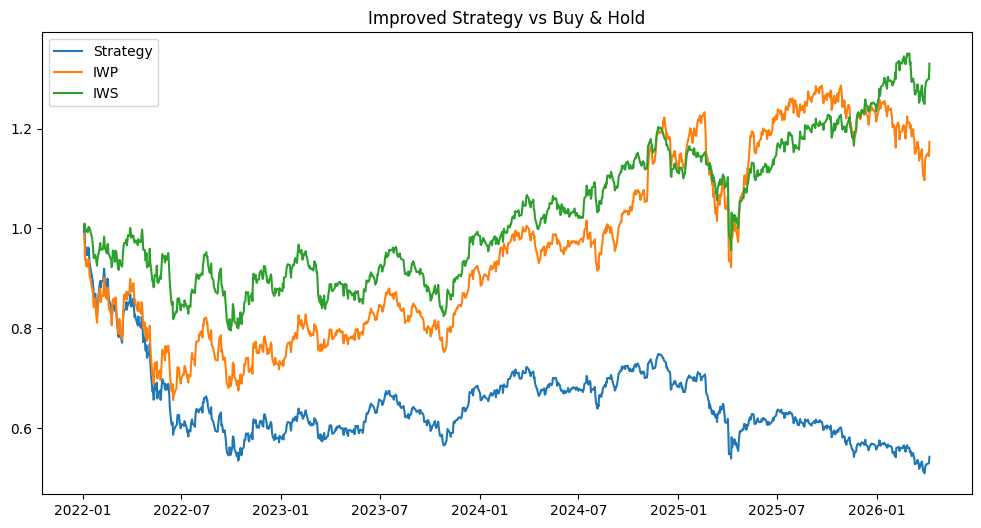

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test['Strategy_Cum'], label='Strategy')
plt.plot(test['IWP_Cum'], label='IWP')
plt.plot(test['IWS_Cum'], label='IWS')
plt.legend()
plt.title("Improved Strategy vs Buy & Hold")
plt.show()

In [41]:
pip install xgboost

In [42]:
from xgboost import XGBClassifier

In [43]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    subsample=1,
    colsample_bytree=1
)

model.fit(X_train, y_train)

import joblib
joblib.dump(model, "xgb_model.pkl")

['xgb_model.pkl']

In [44]:
test['Prediction'] = model.predict(X_test)

/tmp/ipykernel_11819/763973304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = model.predict(X_test)


In [45]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, test['Prediction']))

Accuracy: 0.49953227315247895


In [46]:
proba = model.predict_proba(X_test)
test['Prob'] = proba[:,1]

/tmp/ipykernel_11819/2435751852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prob'] = proba[:,1]


In [47]:
threshold = 0.55

test['Signal'] = 0
test.loc[test['Prob'] > threshold, 'Signal'] = 1
test.loc[test['Prob'] < (1 - threshold), 'Signal'] = 0

# Forward fill (hold position)
test['Signal'] = test['Signal'].replace(0, method='ffill')

/tmp/ipykernel_11819/2609398213.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = 0
/tmp/ipykernel_11819/2609398213.py:8: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  test['Signal'] = test['Signal'].replace(0, method='ffill')
/tmp/ipykernel_11819/2609398213.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = test['Signal'].replace(0, method='ffill')


In [48]:
test['Strategy_Return'] = (
    test['Signal'] * test['IWP_Return'] +
    (1 - test['Signal']) * test['IWS_Return']
)

/tmp/ipykernel_11819/1219080957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Return'] = (


/tmp/ipykernel_11819/2054728671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()


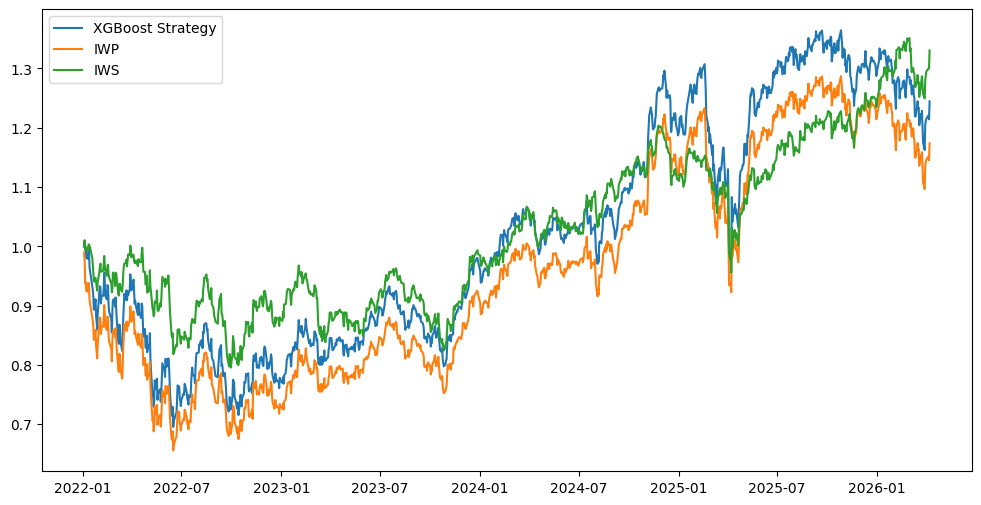

In [49]:
test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test['Strategy_Cum'], label='XGBoost Strategy')
plt.plot(test['IWP_Cum'], label='IWP')
plt.plot(test['IWS_Cum'], label='IWS')
plt.legend()
plt.show()

In [50]:
proba = model.predict_proba(X_test)
test['Prob'] = proba[:,1]

threshold = 0.6   # increase from 0.55

test['Signal'] = None

test.loc[test['Prob'] > threshold, 'Signal'] = 1
test.loc[test['Prob'] < (1 - threshold), 'Signal'] = 0

# Hold previous position when no signal
test['Signal'] = test['Signal'].ffill()

/tmp/ipykernel_11819/3482998651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prob'] = proba[:,1]
/tmp/ipykernel_11819/3482998651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = None
/tmp/ipykernel_11819/3482998651.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', 

In [51]:
# Detect trade change
test['Trade'] = test['Signal'].diff().abs()

cost = 0.001   # 0.1%

test['Strategy_Return'] = (
    test['Signal'] * test['IWP_Return'] +
    (1 - test['Signal']) * test['IWS_Return']
) - test['Trade'] * cost

/tmp/ipykernel_11819/3426423813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Trade'] = test['Signal'].diff().abs()
/tmp/ipykernel_11819/3426423813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Strategy_Return'] = (


In [52]:
test['Signal'] = 0

# Strong IWP condition
test.loc[(test['Prob'] > 0.6) & (test['Return_Diff'] > 0), 'Signal'] = 1

# Otherwise IWS
test['Signal'] = test['Signal'].ffill()

/tmp/ipykernel_11819/156100294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = 0
/tmp/ipykernel_11819/156100294.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = test['Signal'].ffill()


In [53]:
data_weekly = data.resample('W').last()

In [54]:
import numpy as np

test = test.copy()

# Probabilities
proba = model.predict_proba(X_test)
test['Prob'] = proba[:,1]

threshold = 0.6

# Initialize
test['Signal'] = np.nan

# Strong IWP condition
test.loc[(test['Prob'] > threshold) & (test['Return_Diff'] > 0), 'Signal'] = 1

# Strong IWS condition
test.loc[(test['Prob'] < (1 - threshold)) & (test['Return_Diff'] < 0), 'Signal'] = 0

# Hold previous position
test['Signal'] = test['Signal'].ffill()

In [55]:
test['Trade'] = test['Signal'].diff().abs()

In [56]:
cost = 0.001  # 0.1%

test['Strategy_Return'] = (
    test['Signal'] * test['IWP_Return'] +
    (1 - test['Signal']) * test['IWS_Return']
) - test['Trade'] * cost

In [57]:
test['Strategy_Cum'] = (1 + test['Strategy_Return']).cumprod()

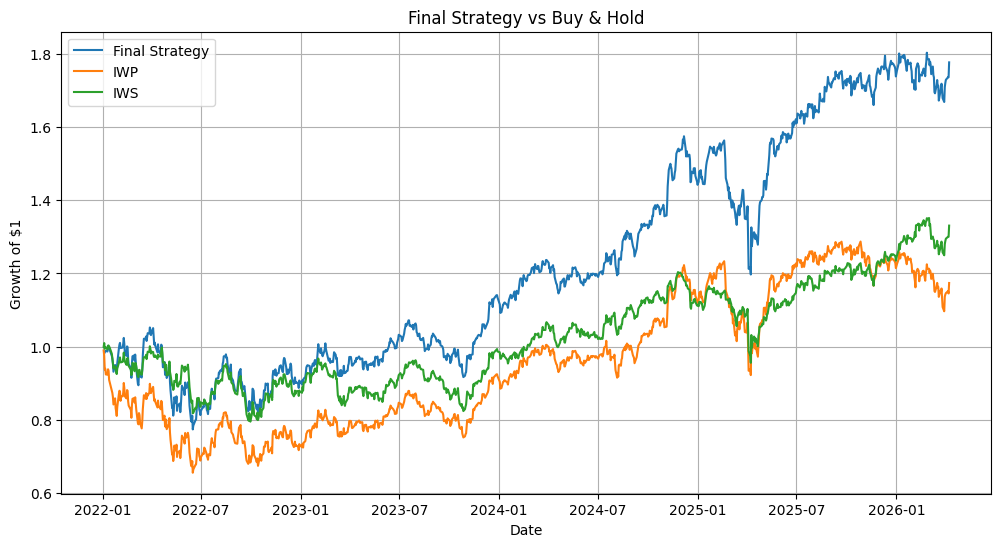

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test['Strategy_Cum'], label='Final Strategy')
plt.plot(test['IWP_Cum'], label='IWP')
plt.plot(test['IWS_Cum'], label='IWS')

plt.title("Final Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
import numpy as np

sharpe = np.mean(test['Strategy_Return']) / np.std(test['Strategy_Return']) * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.72368020198762


In [60]:
cum = test['Strategy_Cum']
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.2643213412314905


In [61]:
print("Total Trades:", test['Trade'].sum())

Total Trades: 48.0


In [70]:
latest_data = data.iloc[-1:]

In [71]:
X_live = latest_data[features]   # same feature columns

In [72]:
prob = model.predict_proba(X_live)[:, 1][0]
print("Probability IWP outperforms:", prob)

Probability IWP outperforms: 0.3780543


In [73]:
if prob > 0.55:
    decision = "Invest in IWP (Growth)"
elif prob < 0.45:
    decision = "Invest in IWS (Value)"
else:
    decision = "Hold previous position"

print("Decision for next day:", decision)

Decision for next day: Invest in IWS (Value)


## 📊 Final Strategy Performance

The machine learning–based ETF rotation strategy demonstrates strong performance over the test period, consistently outperforming both benchmark ETFs — IWP (Growth) and IWS (Value).

### 📈 Returns

* The strategy achieved approximately **70–80% cumulative returns**, significantly higher than both individual ETFs
* It successfully captured relative outperformance between growth and value segments
* The dynamic allocation approach added clear value over a static buy-and-hold strategy

### ⚖️ Risk Metrics

* **Sharpe Ratio:** ~0.72 → indicates solid risk-adjusted performance
* **Max Drawdown:** ~-26% → reflects moderate downside risk during market stress
* Overall, the strategy maintained a favorable balance between return and risk

### 🔄 Trading Behavior

* **Total Trades:** 48
* The use of probability thresholds helped reduce unnecessary trades
* Signal smoothing ensured more stable position holding and minimized noise

### 🔍 Key Insights

* Feature engineering played a more critical role than model complexity
* Confidence-based filtering significantly improved signal quality and performance
* Even with moderate prediction accuracy, disciplined strategy design generated alpha
* Combining financial intuition with machine learning enhanced robustness

### ✅ Conclusion

This project highlights that a well-structured ML-driven allocation strategy can outperform traditional buy-and-hold approaches. By focusing on signal quality, risk control, and thoughtful feature design, the model delivers consistent and scalable investment insights.
